# Grid Search

This notebook is the go-to spot for grid searches whenever improvements to the pipeline are made. The main grid search method is with NLL. A test case of MFA grid search is available, but fine-tuning of weights and penalizations are needed.

## Grid Search with NLL

This section performs grid search on with PyDDM's native loss likelihood calculation.

In [7]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))

### Loading data and preparing for simulation

In [9]:
from ast import literal_eval
from simulation import get_corrected_empirical_distributions
import pandas as pd
import numpy as np

df_raw = pd.read_csv('../1ms_trial_data.csv')
df_raw['RT'] = df_raw['RT']*1000 # adjustment for RT
df_raw['fixation'] = df_raw['fixation'].apply(literal_eval)

to_drop = pd.read_csv("../dropped_trials.csv").rename(columns={"parcode": "sub_id"})

df = df_raw.loc[
    ~df_raw.set_index(["sub_id", "trial"]).index.isin(
        to_drop.set_index(["sub_id", "trial"]).index
    )
    & (~df_raw["hidden"])
]

sub_ids = np.unique(df['sub_id'])

size = 30
sample_sub_ids = np.random.choice(sub_ids, size=size, replace=False)

sample_df = df[df["sub_id"].isin(sample_sub_ids)].copy()
sample_df["choice"] = sample_df["choice"].map({"left": 0, "right": 1})

value_diffs = np.arange(-4, 4.25, 0.25)
legend = {
    "left": {1},
    "right": {2},
    "transition": {0}, 
    "blank_fixation": {4}
}
fixation_col = 'fixation'
left_value_col = 'avgWTP_left'
right_value_col = 'avgWTP_right'

empirical_distributions = get_corrected_empirical_distributions(
    df,
    value_diffs=value_diffs,
    legend=legend,
    fixation_col=fixation_col,
    left_value_col=left_value_col,
    right_value_col=right_value_col,
    cutoff=0.9
)

### Simulating data

With correct scaling, I was able to achieve a reasonable parameter combo from Ian:
model_conditions = {'drift_rate': 0.2, 'theta': 0.5, 'noise': 0.632}

And some alternative explanations: drift rate = 0.3 for m.dt = 0.01 and drift rate = 3 for m.dt = 0.001

In [18]:
from simulation import generate_fixations, simulate
import pyddm

dt = 0.01
seed = 42
model_conditions = {'drift_rate': 0.2, 'theta': 0.5, 'noise': 0.9}

trials = sample_df.loc[sample_df['trial'] % 2 == 1].loc[:, ['avgWTP_left', 'avgWTP_right']]
trials['fixation'] = None

rng = np.random.default_rng(42)
trials_dict = []
for idx, r in trials.iterrows():
    fx = generate_fixations(
        dt, 
        r.avgWTP_left - r.avgWTP_right, 
        empirical_distributions,
        rng=rng
    )
    if fx is not None:
        trials_dict.append({
            "avgWTP_left": r.avgWTP_left,
            "avgWTP_right": r.avgWTP_right,
            "fixation": fx
        })

results_df = simulate(dt, model_conditions, trials_dict, seed=seed, save_results=False)
# results_df['sub_id'] = f'seed{seed}_subjects{size}_sim'
# results_df['trial'] = range(1, len(trials_clean) + 1)
# results_df = results_df.rename(columns={'fixation': 'fix_sequence'})
results_df = results_df.drop(columns = ['trajectory'])

sample = pyddm.Sample.from_pandas_dataframe(
    results_df,
    choice_column_name="choice",
    rt_column_name="RT",
    choice_names=("left", "right")
)

print(f'Average RT: {results_df["RT"].mean():.2f} ms (out of {len(results_df)} trials)')
results_df.head()

Average RT: 1.27 ms (out of 300 trials)


,avgWTP_left,avgWTP_right,fixation,RT,choice
0,1.00,1.0,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",2.66,1
1,4.50,4.5,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3.21,1
2,4.75,4.0,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, ...",0.60,0
3,1.00,1.0,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, ...",1.98,1
4,1.00,1.0,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, ...",0.29,0


### Comparing the frequency of stimuli value pairs

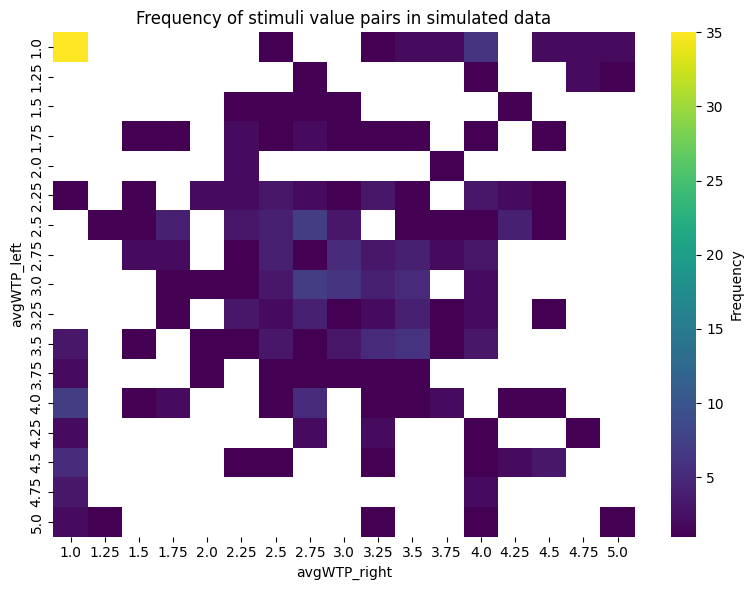

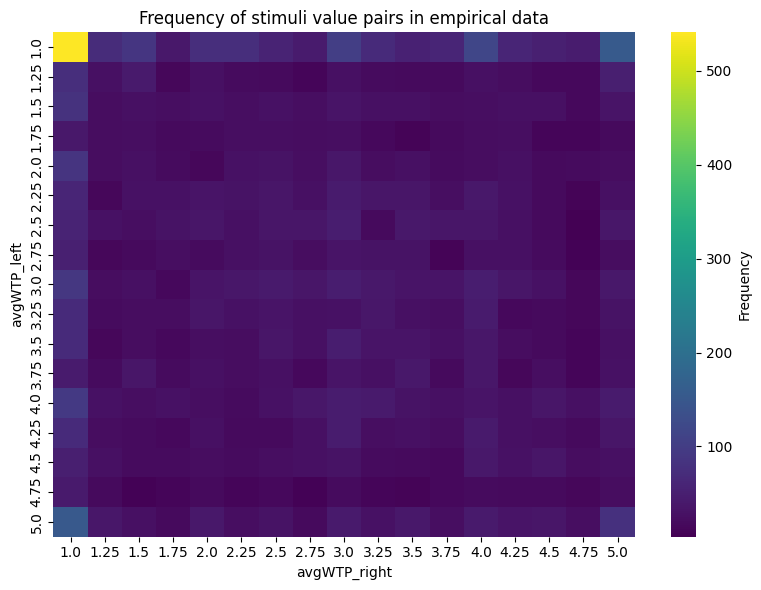

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Plot heatmap for simulated data

# 1. Count frequency of each (avgWTP_left, avgWTP_right) pair
heatmap_df = (
    results_df
    .groupby(["avgWTP_left", "avgWTP_right"])
    .size()
    .reset_index(name="frequency")
)

# 2. Pivot to matrix form
heatmap_matrix = heatmap_df.pivot(
    index="avgWTP_left",
    columns="avgWTP_right",
    values="frequency"
).fillna(0)

# 3. MASK ZEROS (this is the new part)
mask = heatmap_matrix == 0

# 4. Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_matrix,
    mask=mask,              # <- makes zeros white
    cmap="viridis",
    cbar_kws={"label": "Frequency"}
)

plt.xlabel("avgWTP_right")
plt.ylabel("avgWTP_left")
plt.title("Frequency of stimuli value pairs in simulated data")
plt.tight_layout()
plt.show()

### Repeat for empirical data

heatmap_df = (
    df
    .groupby(["avgWTP_left", "avgWTP_right"])
    .size()
    .reset_index(name="frequency")
)

heatmap_matrix = heatmap_df.pivot(
    index="avgWTP_left",
    columns="avgWTP_right",
    values="frequency"
).fillna(0)

mask = heatmap_matrix == 0

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_matrix,
    mask=mask,              # <- makes zeros white
    cmap="viridis",
    cbar_kws={"label": "Frequency"}
)

plt.xlabel("avgWTP_right")
plt.ylabel("avgWTP_left")
plt.title("Frequency of stimuli value pairs in empirical data")
plt.tight_layout()
plt.show()



### Conducting grid search

In [24]:
import itertools
import numpy as np

d_vals = np.linspace(0.2, 2.0, 7)
noise_vals = np.linspace(0.2, 0.9, 8)

grid = list(itertools.product(d_vals, noise_vals))

In [26]:
from pyddm.models.loss import LossLikelihood

results = []

def drift_function(x, t, d, avgWTP_left, avgWTP_right, fixation):
    idx = min(int(t / 0.001), len(fixation) - 1)
    f = fixation[idx]
    theta = model_conditions['theta'] # For theta as a constant
    if f == 0:   # no fixation
        drift_val =  0
    elif f == 1:
        drift_val = d * (avgWTP_left - theta * avgWTP_right)
    else:
        drift_val = d * (theta * avgWTP_left - avgWTP_right)
    
    return np.ones_like(x) * drift_val

def noise_function(x, t, noise):
    return np.ones_like(x) * noise

for d_val, noise_val in grid:
    m = pyddm.gddm(
        drift=drift_function,
        noise=noise_function,
        parameters={"d": d_val, "noise": noise_val},
        conditions=["avgWTP_left","avgWTP_right","fixation"],
        choice_names=("left","right"),
        T_dur=10,
        dx=0.005,
        dt=dt
    )

    lossfunc = LossLikelihood(sample=sample, model=m, dt=m.dt, T_dur=m.T_dur)
    print(f"Running params [{d_val}, {noise_val}]...")
    nll = lossfunc.loss(m)
    print(f"NLL = {nll}")
    results.append({"drift": d_val, "noise": noise_val, "nll": nll})

Running params [0.2, 0.2]...
NLL = 1850.416363734391
Running params [0.2, 0.3]...
NLL = 1588.077638147149
Running params [0.2, 0.4]...
NLL = 1255.5518430719303
Running params [0.2, 0.5]...
NLL = 970.9575587166322
Running params [0.2, 0.6]...
NLL = 778.6525666580728
Running params [0.2, 0.7]...
NLL = 666.6942625872917
Running params [0.2, 0.8]...
NLL = 609.1271414766021
Running params [0.2, 0.9]...
NLL = 587.4125104955687
Running params [0.5, 0.2]...
NLL = 1640.221805273715
Running params [0.5, 0.3]...
NLL = 1482.6686754314317
Running params [0.5, 0.4]...
NLL = 1322.3190541194795
Running params [0.5, 0.5]...
NLL = 1148.2254618097552
Running params [0.5, 0.6]...
NLL = 986.4644040538227
Running params [0.5, 0.7]...
NLL = 861.933782959235
Running params [0.5, 0.8]...
NLL = 778.2583057233766
Running params [0.5, 0.9]...
NLL = 729.914549236362
Running params [0.8, 0.2]...
NLL = 1591.4677375657936
Running params [0.8, 0.3]...
NLL = 1488.2603682026977
Running params [0.8, 0.4]...
NLL = 1373.80

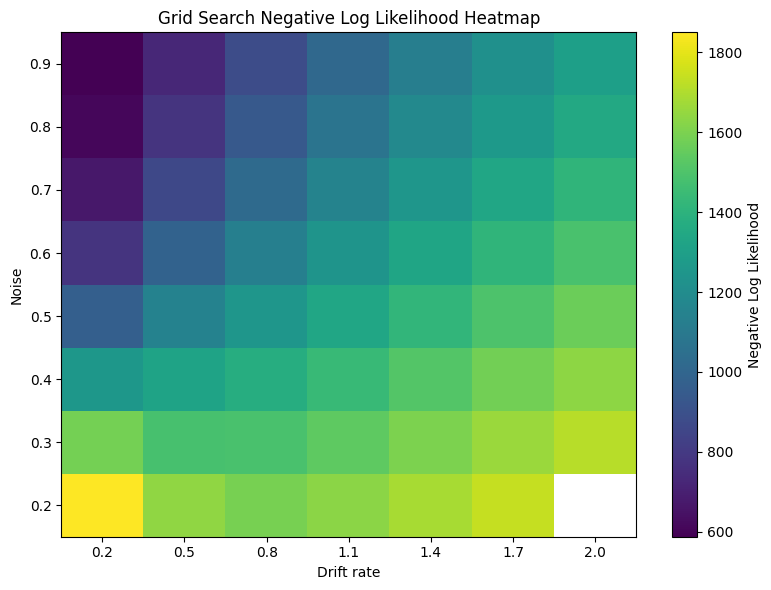

In [27]:
results_df = pd.DataFrame(results)

heatmap_data = results_df.pivot(
    index="noise",
    columns="drift",
    values="nll"
)

plt.figure(figsize=(8,6))
im = plt.imshow(
    heatmap_data.values,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(im, label="Negative Log Likelihood")

plt.xticks(
    range(len(heatmap_data.columns)),
    labels=np.round(heatmap_data.columns, 3)
)
plt.yticks(
    range(len(heatmap_data.index)),
    labels=np.round(heatmap_data.index, 3)
)

plt.xlabel("Drift rate")
plt.ylabel("Noise")
plt.title("Grid Search Negative Log Likelihood Heatmap")
plt.tight_layout()
plt.show()

## Grid Search with MFA Loss

In [ ]:
from ast import literal_eval
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_raw = pd.read_csv('/Users/braydenchien/Desktop/Enkavilab/DDM/1ms_trial_data.csv')
df_raw['RT'] = df_raw['RT']*1000 # adjustment for RT
df_raw['fixation'] = df_raw['fixation'].apply(literal_eval)

to_drop = pd.read_csv("dropped_trials.csv").rename(columns={"parcode": "sub_id"})

df = df_raw[
    ~df_raw.set_index(["sub_id", "trial"]).index.isin(
        to_drop.set_index(["sub_id", "trial"]).index
    )
]

size = 30
sub_ids = np.unique(df['sub_id'])
sample_sub_ids = np.random.choice(sub_ids, size=size, replace=False)

sample_df = df[df["sub_id"].isin(sample_sub_ids)]
sample_df["choice"] = sample_df["choice"].map({"left": 0, "right": 1})

In [ ]:
from pyddm.preprocessing.dataset import rasterize_data
from mfa import compute_mfa

samples_rasterized = rasterize_data(sample_df, subject_col='sub_id',trial_col='trial',seq_col='fixation')
samples_rasterized['fix_dur'] = samples_rasterized.apply(
    lambda r: r['fix_end'] - r['fix_start'],
    axis=1
)

samples_rasterized['fix_num'] = (
    samples_rasterized
    .groupby(['sub_id', 'trial'])
    .cumcount() + 1
)

samples_rasterized['fix_num_rev'] = (
    samples_rasterized
    .groupby(['sub_id', 'trial'])
    .cumcount(ascending=False) + 1
)

samp_mfa = compute_mfa(samples_rasterized)

In [ ]:
from simulation import get_corrected_empirical_distributions

value_diffs = np.arange(-4, 4.25, 0.25)
legend = {
    "left": {1},
    "right": {2},
    "transition": {0}, 
    "blank_fixation": {4}
}
fixation_col = 'fixation'
left_value_col = 'avgWTP_left'
right_value_col = 'avgWTP_right'
cutoff = 0.95

empirical_distributions = get_corrected_empirical_distributions(
    sample_df,
    value_diffs=value_diffs,
    legend=legend,
    fixation_col=fixation_col,
    left_value_col=left_value_col,
    right_value_col=right_value_col,
    cutoff=cutoff
)

In [ ]:
from simulation import generate_fixations

# Let's try using all trials instead of half
# trials = sample_df.loc[sample_df['trial'] % 2 == 1].loc[:, ['avgWTP_left', 'avgWTP_right']]
trials = sample_df.loc[:, ['avgWTP_left', 'avgWTP_right']]
trials['fixation'] = None

rows = []
for idx, r in trials.iterrows():
    fx = generate_fixations(dt, r.avgWTP_left - r.avgWTP_right, empirical_distributions)
    if fx is not None:
        rows.append((idx, fx))

trials_clean = trials.loc[[i for i, _ in rows]].copy()
trials_clean['fixation'] = [fx for _, fx in rows]
my_trials = trials_clean.to_dict(orient="records")

In [ ]:
from mfa import model_free_loss
from simulation import simulate

dt = 0.01
seed = 42

d_vals = np.linspace(0.5, 2.0, 4)
noise_vals = np.linspace(0.2, 1.0, 5)

grid = list(itertools.product(d_vals, noise_vals))

results = []

for d_val, noise_val in grid:
    model_conditions = {'drift_rate': d_val, 'theta': 0.5, 'noise': noise_val}

    temp_trials = trials.copy()

    print(f"Simulating with params [{d_val}, {noise_val}]...")

    results_df = simulate(dt, model_conditions, my_trials, seed=seed, save_results=False)
    results_df['sub_id'] = f'seed{seed}_subjects{size}_sim'
    results_df['trial'] = range(1, len(trials_clean) + 1)
    # results_df = results_df.rename(columns={'fixation': 'fix_sequence'})
    results_df = results_df.drop(columns = ['trajectory'])

    results_rasterized = rasterize_data(results_df, subject_col='sub_id',trial_col='trial',seq_col='fixation')
    results_rasterized['fix_dur'] = results_rasterized.apply(
        lambda r: r['fix_end'] - r['fix_start'],
        axis=1
    )

    results_rasterized['fix_num'] = (
        results_rasterized
        .groupby(['sub_id', 'trial'])
        .cumcount() + 1
    )

    results_rasterized['fix_num_rev'] = (
        results_rasterized
        .groupby(['sub_id', 'trial'])
        .cumcount(ascending=False) + 1
    )

    sim_mfa = compute_mfa(results_rasterized)
    loss = model_free_loss(samp_mfa, sim_mfa)

    print(f"MFA loss = {loss}")
    
    results.append({"drift": d_val, "noise": noise_val, "mfa_loss": loss})

In [ ]:
results_df = pd.DataFrame(results)

heatmap_data = results_df.pivot(
    index="noise",
    columns="drift",
    values="mfa_loss"
)

plt.figure(figsize=(8,6))
im = plt.imshow(
    heatmap_data.values,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(im, label="Model-Free Analysis Loss")

plt.xticks(
    range(len(heatmap_data.columns)),
    labels=np.round(heatmap_data.columns, 3)
)
plt.yticks(
    range(len(heatmap_data.index)),
    labels=np.round(heatmap_data.index, 3)
)

plt.xlabel("Drift rate")
plt.ylabel("Noise")
plt.title("Grid Search Model-Free Analysis Heatmap")
plt.tight_layout()
plt.show()

This rudimentary grid search confirms that changing the parameters has large effects on the quality of simulated data. Unfortunately, the method that I've created only works in a narrow parameter space relative to true data.